In [2]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import os

In [3]:
A = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images/100000039159562031368112550794429920461.npz')['data']


In [4]:
A.shape

(256, 256)

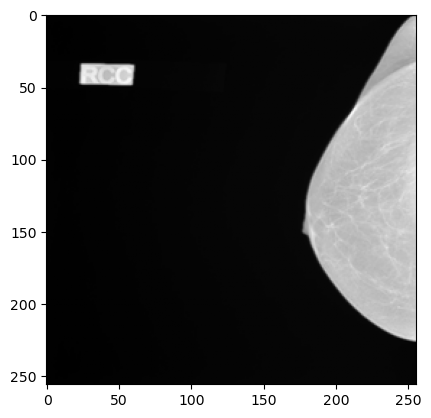

In [5]:
plt.imshow(A, cmap='gray')

In [6]:
# Check image path

omama_dir_path = "/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images"
if not os.path.exists(omama_dir_path):
    print(f"File not found: {omama_dir_path}")
    print("Please update dicom_path with a valid image file path")
else:
    print(f"Found DICOM folder: {os.path.basename(omama_dir_path)}")
    omama_folder = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images")
    IDs = sorted(str(file) for file in omama_folder.rglob("*.npz"))
    print(len(IDs))

Found DICOM folder: images
163568


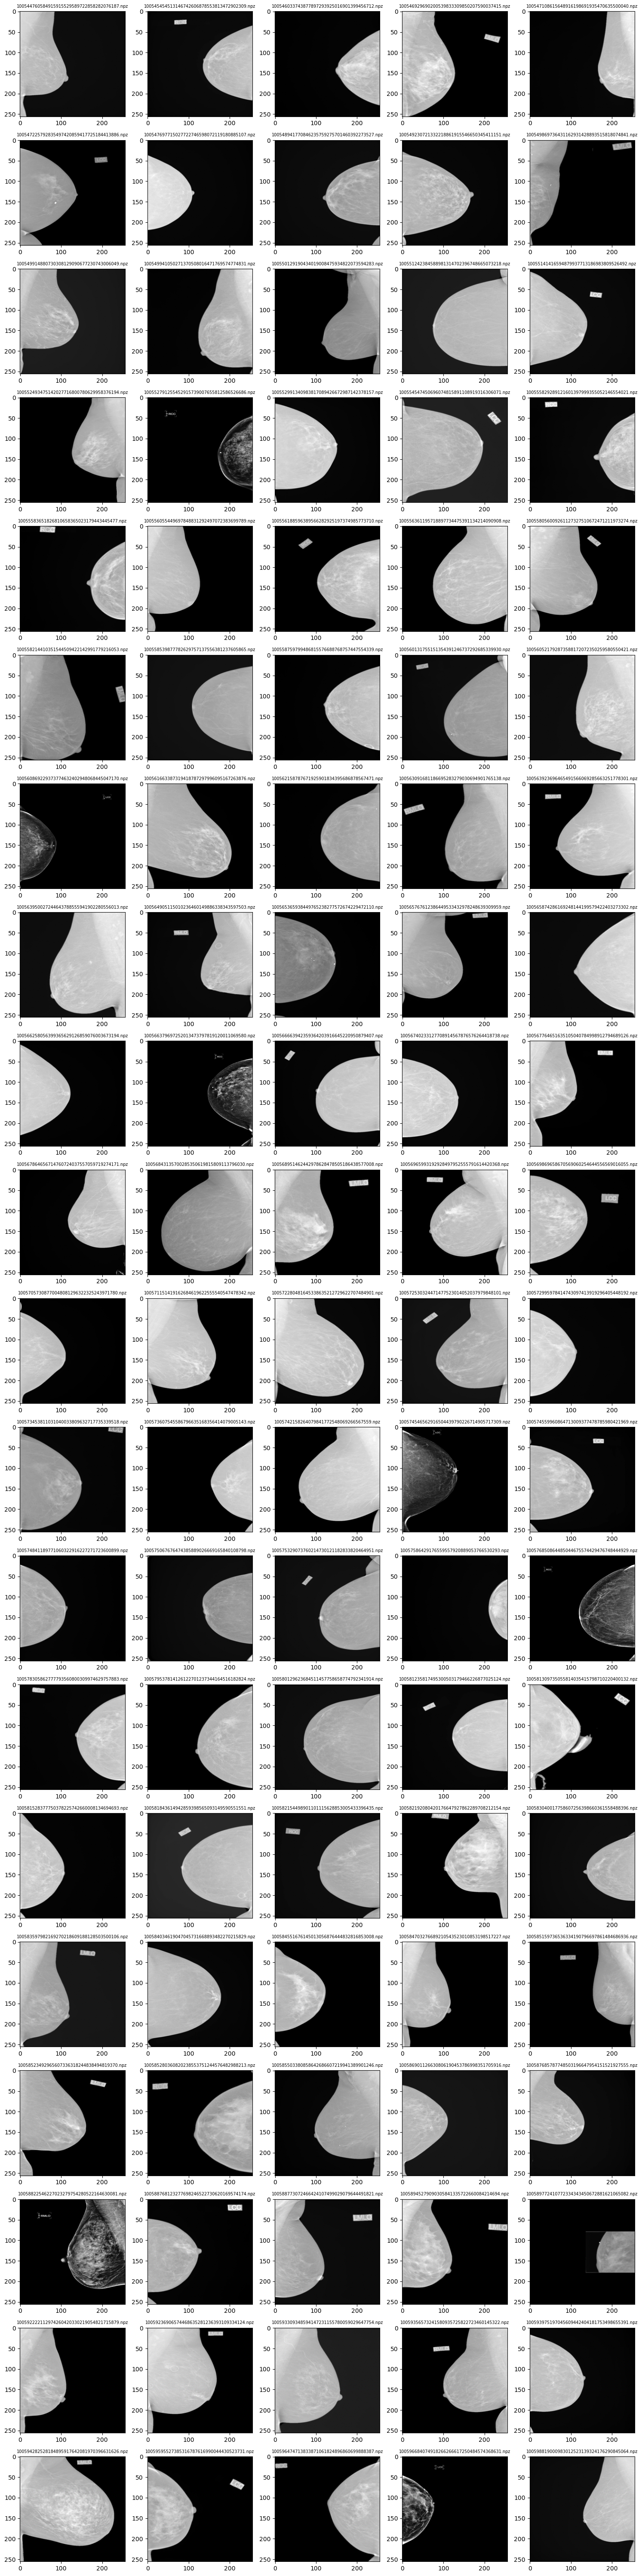

In [15]:
images_path = IDs[1200:1300]
cols = 5
rows = int(len(images_path)/cols)
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.ravel()

for ax, image_path in zip(axes, images_path) :
    image = np.load(image_path)['data']
    ax.imshow(image, cmap = "gray")
    ax.set_title(Path(image_path).name, fontsize=7)

plt.tight_layout()
plt.show()

In [8]:
size = {}
for image_path in IDs[:1000] :
    image = np.load(image_path)['data']
    if image.shape not in size.keys() :
        size[image.shape] = 0
    size[image.shape] += 1

In [22]:
for dim, count in size.items() :
    print(f'{dim}\t\t{count}')

(256, 256)		1000


In [9]:
print(f'{"Name":<50}{"Min":<5}{"Max":<5}{"Mean":<20}{"STD":<20}')
print("-"*120)
for image_path in IDs[:5] :
    image = np.load(image_path)['data']
    print(f'{Path(image_path).name:<50}{image.min():<5}{image.max():<5}{image.mean():<20}{image.std():<20}')

Name                                              Min  Max  Mean                STD                 
------------------------------------------------------------------------------------------------------------------------
100000039159562031368112550794429920461.npz       0    253  38.05296325683594   72.3605865899825    
100000201190603337191863609201535272336.npz       0    252  65.14949035644531   75.2216216599838    
100001062780186333300160449315992055513.npz       0    255  53.90507507324219   78.28648179015052   
100001667933097808112506050500785212069.npz       0    248  70.52226257324219   92.67416773810325   
100002819211671685540712131744483029257.npz       0    255  15.203125           32.26602177041155   


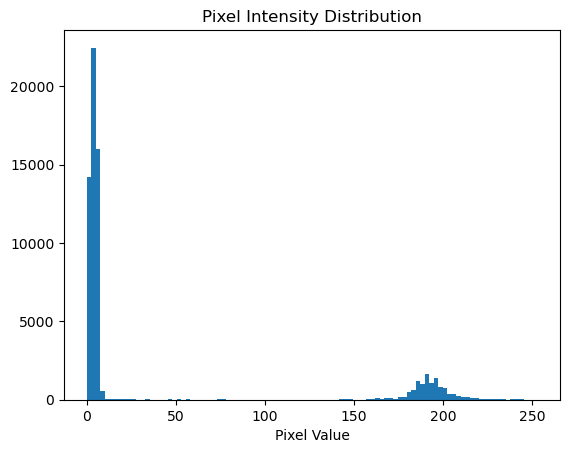

In [11]:
image = np.load(IDs[0])["data"]
plt.hist(image.ravel(), bins=100)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.show()